In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns

palette = sns.husl_palette(h=.7)
rc = {
    'figure.dpi': 300,
    'font.size': 6,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 6,  
    'legend.fontsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.edgecolor': 'k',
    'axes.linewidth': 0.5,
    'axes.grid': False,
    'axes.prop_cycle': plt.cycler(color=sns.husl_palette(h=.7)),
    'figure.figsize': (7, 2),
    'xtick.major.pad': -3,
    'ytick.major.pad': -3
}

plt.rcParams.update(rc)  # Apply the style
sns.set_theme(style="white", font='Arial', rc=rc)


In [3]:
RACE_MAP = {
    '1': 'American Indian or Alaska Native',
    '2': 'Asian',
    '3': 'Black or African American',
    '4': 'Native Hawaiian or Other Pacific Islander',
    '5': 'White'
}

In [4]:
# SET SEED
np.random.seed(42)

def bootstrap(data, stat_func, n_bootstrap=1000, alpha=0.95):
    stat = stat_func(data)
    
    bootstrap_stats = []
    for _ in range(n_bootstrap):
        # Sample with replacement
        boot_sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_stats.append(stat_func(boot_sample))
    
    ci_low, ci_high = np.percentile(bootstrap_stats, 
                                   [(1 - alpha) * 100/2, 
                                    (1 + alpha) * 100/2])
    
    return stat, ci_low, ci_high, bootstrap_stats

def calc_cv(data):
    return np.std(data) / np.mean(data) * 100

def calc_ratio(x, y):
    ratios = [x[i]/y[i] for i in range(len(x))]
    return ratios

def find_inter_cv(setpoint_df, code):
    """Calculate inter-individual CV with bootstrap confidence intervals"""
    code_df = setpoint_df[setpoint_df['code'] == code]
    setpoints = code_df['setpoint'].values
    return bootstrap(setpoints, calc_cv)

def find_intra_cv(setpoint_df, code, time_period):
    """Calculate intra-individual CV with confidence intervals"""
    if time_period == 'longterm':
        code_df = setpoint_df[setpoint_df['code'] == code]
        uncertainties = code_df['cv'].values 
        return bootstrap(uncertainties, np.mean)  # Using mean for uncertainties
        
    elif time_period == 'shortterm':
        eflm_code = eflm_variation[eflm_variation['Code'] == code]
        cv = eflm_code[eflm_code['Matrix'] == 'Intra-Patient']['Median CV Estimate'].values[0]
        ci_low = eflm_code[eflm_code['Matrix'] == 'Intra-Patient']['Lower CI Limit'].values[0]
        ci_high = eflm_code[eflm_code['Matrix'] == 'Intra-Patient']['Higher CI Limit'].values[0]
        return cv, ci_low, ci_high, None


In [5]:
def calculate_cvs_for_group(df, group_name='All'):
    """Calculate CVs for a specific group of patients"""
    results = []
    
    for code in df['code'].unique():
        # Inter-individual CV
        size = sum(df['code']==code)
        
        inter_cv, inter_low, inter_high, inter_bootstrap = find_inter_cv(df, code)
        results.append([code, group_name, 'Inter-patient', inter_cv, inter_low, inter_high, size])
        
        # Long-term intra-individual CV
        intra_cv_long, intra_long_low, intra_long_high, intra_long_bootstrap = find_intra_cv(df, code, 'longterm')
        results.append([code, group_name, 'Long-term intra-patient', intra_cv_long, intra_long_low, intra_long_high, size])
        
        # Short-term intra-individual CV
        if group_name == 'All':
            ratio_bootstrap = calc_ratio(intra_long_bootstrap, inter_bootstrap)
            ratio_mean = np.mean(ratio_bootstrap)
            ratio_low = np.percentile(ratio_bootstrap, 2.5)
            ratio_high = np.percentile(ratio_bootstrap, 97.5)
            results.append([code, group_name, 'Ratio', ratio_mean, ratio_low, ratio_high, size])
        
            intra_cv_short, intra_short_low, intra_short_high, _ = find_intra_cv(df, code, 'shortterm')
            results.append([code, group_name, 'Short-term intra-patient', intra_cv_short, intra_short_low, intra_short_high, size])
            
    return results


In [6]:
pwd

'/Users/aashnashah/Desktop/ssh_mount/SETPOINT/notebooks'

In [7]:
cbc_subject_stats = pd.read_csv('../results/summary_statistics/cbc_subject_statistics.csv')
demographics_df = pd.read_csv('../data/processed/demographics.csv')

In [31]:
gap = 30
tests = 5
year = 2024
setpoint_df = pd.read_csv(f'../results/setpoint_calculations/setpoints_gap:{gap}_tests:{tests}_year:{year}.csv')

merged = pd.merge(setpoint_df, cbc_subject_stats, on=['subject_id', 'code'], how='left')
setpoint_df = pd.merge(merged, demographics_df, on='subject_id', how='left')
setpoint_df.percentage_tests_within_reference = setpoint_df.percentage_tests_within_reference.str.rstrip('%').astype(float)

print('Maximum Time Period: ', setpoint_df['days_between_first_and_last'].max()/365, 'years')
print('Minimum Time Period: ', setpoint_df['days_between_first_and_last'].min()/365, 'years')
print('Average Number of Tests per Patient: ', setpoint_df['num_tests_taken'].mean())

eflm_variation = pd.read_csv('../data/eflm_cbc_variation.csv', sep='\t')

# Create results for all groups
all_results = []
all_results.extend(calculate_cvs_for_group(setpoint_df, 'All'))

# Gender results
setpoint_df['Gender'] = setpoint_df['Gender'].apply(lambda x: 'Female' if x == 'F' else 'Male')
for gender in ['Female', 'Male']:
    gender_df = setpoint_df[setpoint_df['Gender'] == gender]
    all_results.extend(calculate_cvs_for_group(gender_df, f'{gender}'))

# Ethnicity results
for ethnicity in setpoint_df['Ethnicity'].unique():
    ethnicity_df = setpoint_df[setpoint_df['Ethnicity'] == ethnicity]
    all_results.extend(calculate_cvs_for_group(ethnicity_df, f'{ethnicity}'))

# Race results
setpoint_df['Race'] = setpoint_df['Race'].apply(lambda x: 'White' if x == 5 else 'Non-White')
for race in setpoint_df['Race'].unique():
    race_df = setpoint_df[setpoint_df['Race'] == race]
    all_results.extend(calculate_cvs_for_group(race_df, f'{race}'))

# Create DataFrame
results_df = pd.DataFrame(all_results, columns=['Code', 'Group', 'Type', 'CV', 'CI_Low', 'CI_High', 'Size'])


Maximum Time Period:  24.23835616438356 years
Minimum Time Period:  0.8794520547945206 years
Average Number of Tests per Patient:  60.113902122130796


/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_65605/1066915847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['title'] = all_df['Code'].astype(str) + '\n(n=' + all_df['Size'].astype(str) + ')'
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_65605/1066915847.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='title', y='CV', hue='Type', data=all_df, ci=None)


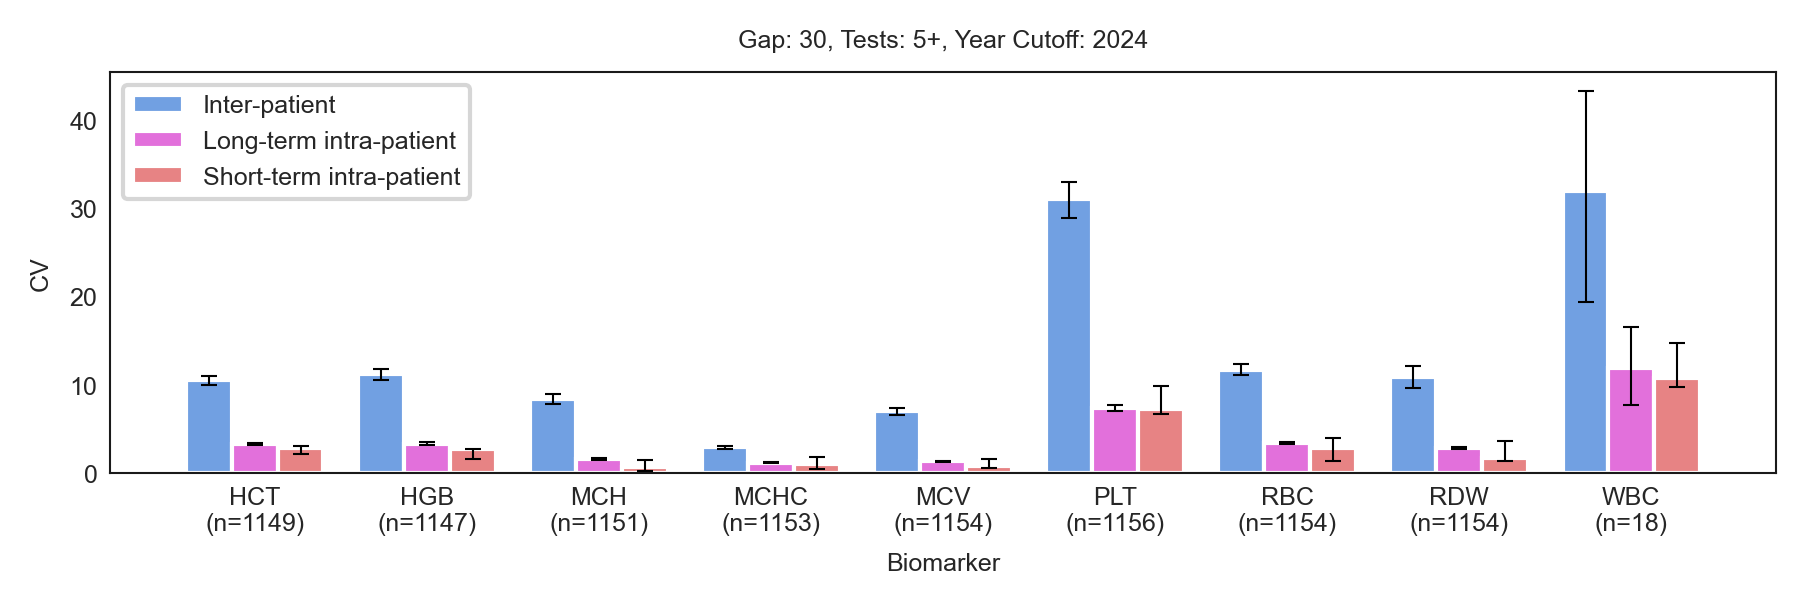

In [32]:
all_df = results_df[(results_df['Group']=='All') & (results_df['Type'] != 'Ratio')]
all_df['title'] = all_df['Code'].astype(str) + '\n(n=' + all_df['Size'].astype(str) + ')'

plt.figure(figsize=(6, 2))
# Create the base plot
ax = sns.barplot(x='title', y='CV', hue='Type', data=all_df, ci=None)

# Calculate positions for error bars
n_types = len(all_df['Type'].unique())
width = 0.8  # default bar width in seaborn
offsets = np.linspace(-(width/2)*(1-1/n_types), (width/2)*(1-1/n_types), n_types)

# Add error bars for each type
for i, type_name in enumerate(all_df['Type'].unique()):
    type_data = all_df[all_df['Type'] == type_name]
    x_positions = [x + offsets[i] for x in range(len(type_data))]
    yerr = [type_data['CV'] - type_data['CI_Low'], 
            type_data['CI_High'] - type_data['CV']]
    plt.errorbar(x=x_positions, y=type_data['CV'], yerr=yerr, fmt='none', c='black', 
                 linewidth=0.5, capsize=2, capthick=0.5)

plt.title(f'Gap: {gap}, Tests: {tests}+, Year Cutoff: {year}')
plt.xticks()
plt.xlabel('Biomarker')
plt.legend(title='')
plt.tight_layout()
plt.show()

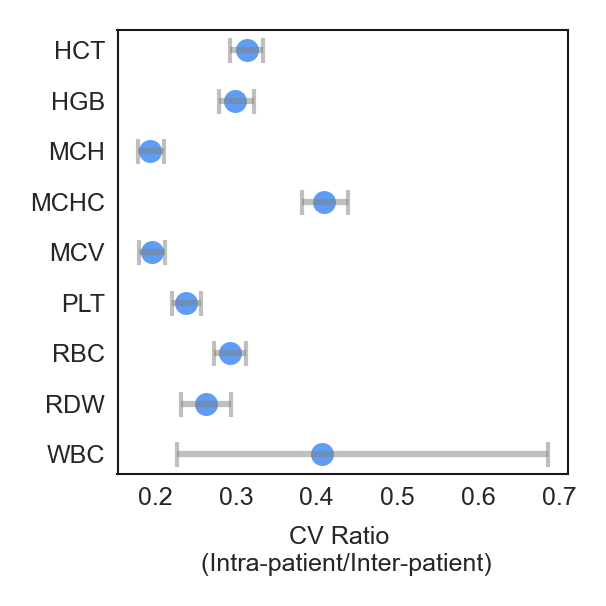

In [74]:
# Filter for just the ratio data
ratio_df = results_df[results_df['Type']=='Ratio']

# Create the scatter plot
plt.figure(figsize=(2, 2))
sns.scatterplot(data=ratio_df, x='CV', y='Code')

# Add error bars
plt.errorbar(x=ratio_df['CV'], y=range(len(ratio_df)), 
            xerr=[ratio_df['CV'] - ratio_df['CI_Low'], 
                  ratio_df['CI_High'] - ratio_df['CV']],
            fmt='none', c='gray', alpha=0.5, capsize=3)

plt.xlabel('CV Ratio \n (Intra-patient/Inter-patient)')
plt.ylabel('')
plt.tight_layout()
plt.show()

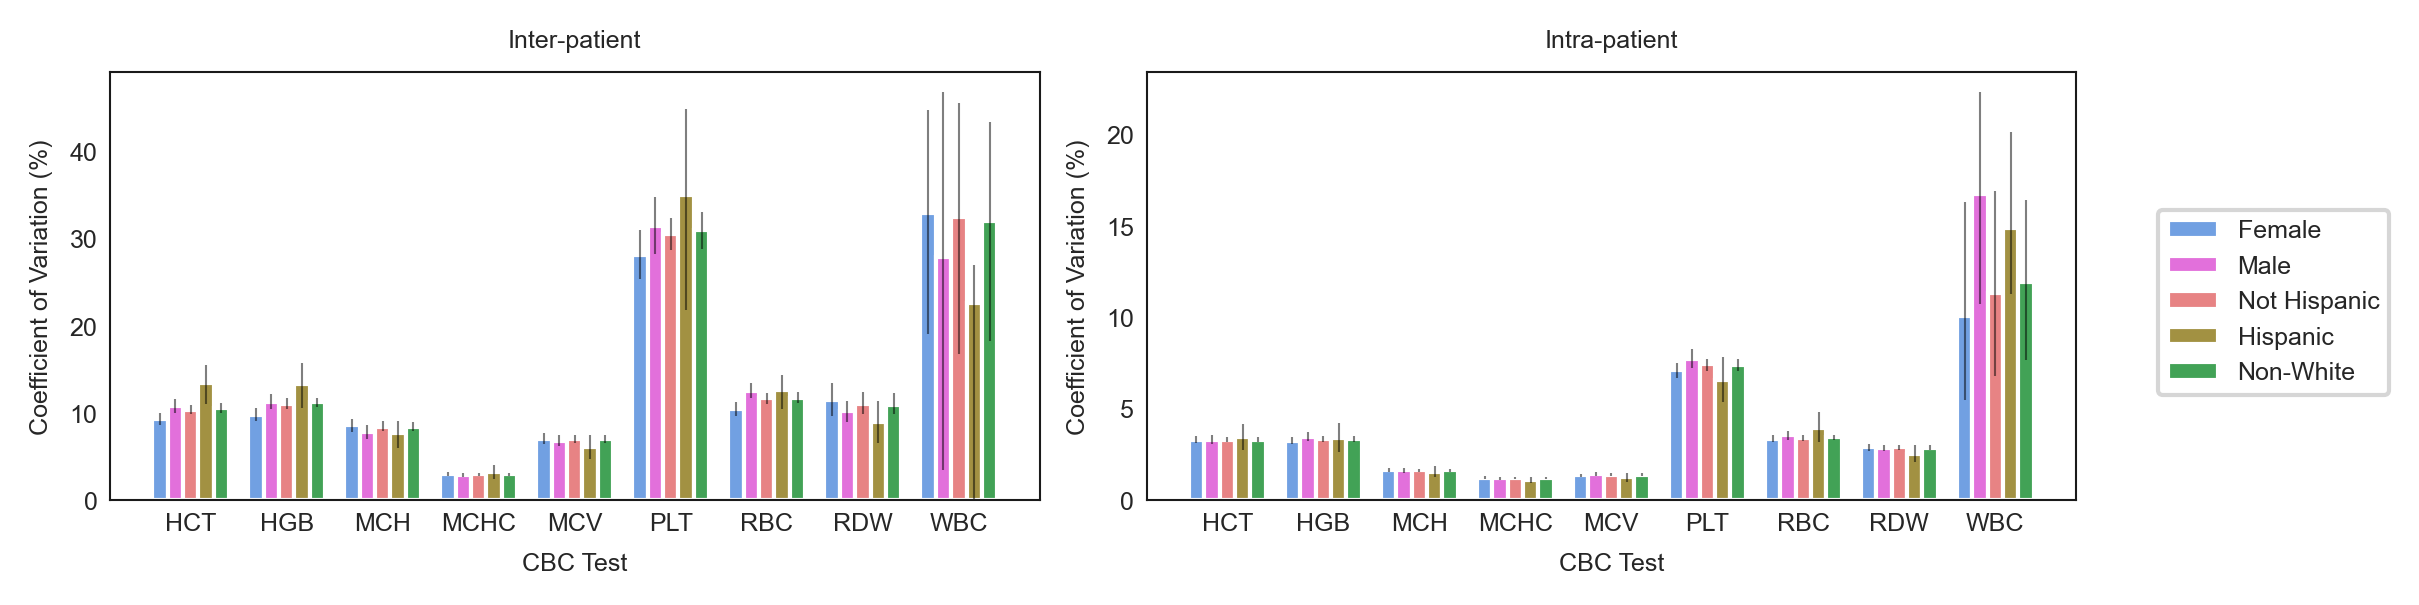

In [75]:
def create_barplot_with_errors(data, plot_type, ax):
    """
    Create a barplot with error bars for either Inter or Intra-Long data
    """
    # Create base barplot
    sns.barplot(
        data=data[data['Type'] == plot_type],
        x='Code',
        y='CV',
        hue='Group',
        ax=ax
    )
    
    # Add error bars
    type_df = data[data['Type'] == plot_type]
    n_groups = len(type_df['Group'].unique())
    width = 0.8 / n_groups
    
    for idx, group in enumerate(type_df['Group'].unique()):
        group_data = type_df[type_df['Group'] == group].sort_values(by='Code')
        x_positions = np.arange(len(group_data['Code'].unique())) + idx * width - (n_groups-1) * width/2
        
        ax.errorbar(
            x=x_positions,
            y=group_data['CV'],
            yerr=[group_data['CV'] - group_data['CI_Low'], 
                  group_data['CI_High'] - group_data['CV']],
            fmt='none',
            c='black',
            capthick=0.5,
            linewidth=0.5,
            alpha=0.5
        )
    
    # Set axis properties
    ax.set_title(f'{plot_type.replace("Long-term ", "").capitalize()}')
    ax.set_xlabel('CBC Test')
    ax.set_ylabel('Coefficient of Variation (%)')
    ax.tick_params(axis='x')
    ax.get_legend().remove()

def create_cv_comparison_plot(group_df):
    """
    Create a comparison plot of Inter and Intra-Long CV values
    
    Parameters:
    - group_df: DataFrame containing the CV data
    """
    # Filter data
    plot_df = group_df[group_df['Type'].isin(['Inter-patient', 'Long-term intra-patient'])]
    
    # Create figure and axes
    fig, (ax1, ax2) = plt.subplots(1, 2)
    
    # Create both plots
    create_barplot_with_errors(plot_df, 'Inter-patient', ax1)
    create_barplot_with_errors(plot_df, 'Long-term intra-patient', ax2)
    
    # Add single legend to figure
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, 
              bbox_to_anchor=(1.02, 0.5),
              loc='center left',
              title='')
    
    plt.tight_layout()
    return fig

# Create and display the plot
group_df = results_df[results_df['Group'] != 'All']
fig = create_cv_comparison_plot(group_df)
plt.show()